In [ ]:
!ls

best.pt  Placas.zip  sample_data


In [ ]:
!unzip Placas.zip

Archive:  Placas.zip
   creating: Placas/
  inflating: Placas/ADG22H.jpg       
  inflating: Placas/AFX91C.jpg       
  inflating: Placas/AOZ48G.jpg       
  inflating: Placas/AZA70F.jpg       
  inflating: Placas/BDV08.jpg        
  inflating: Placas/CIW062.jpg       
  inflating: Placas/DBI463.jpg       
  inflating: Placas/DHT578.png       
  inflating: Placas/DIF77H.jpg       
  inflating: Placas/DJN996.jpg       
  inflating: Placas/DJY681.jpg       
  inflating: Placas/DKU983.jpg       
  inflating: Placas/DQS096.jpg       
  inflating: Placas/DUL56G.jpg       
  inflating: Placas/EBS862.jpg       
  inflating: Placas/EFW512.jpg       
  inflating: Placas/EOS64D.jpg       
  inflating: Placas/EZI04D.jpg       
  inflating: Placas/FGL91C.jpg       
  inflating: Placas/FOY022.jpg       
  inflating: Placas/FPM832.jpg       
  inflating: Placas/FQX673.jpg       
  inflating: Placas/FSY718.jpg       
  inflating: Placas/FZM790.jpg       
  inflating: Placas/FZR555.jpg       
  inflat

In [ ]:
!unzip PlacasBlancas.zip

Archive:  PlacasBlancas.zip
   creating: PlacasBlancas/
  inflating: PlacasBlancas/ESP600.jpg  
  inflating: PlacasBlancas/EXU952.jpg  
  inflating: PlacasBlancas/FSV222.jpg  
  inflating: PlacasBlancas/GUU715.jpg  
  inflating: PlacasBlancas/JKX482.jpg  
  inflating: PlacasBlancas/JTY999.jpg  
  inflating: PlacasBlancas/JUY094.jpg  
  inflating: PlacasBlancas/JVM489.jpg  
  inflating: PlacasBlancas/KSQ832.jpg  
  inflating: PlacasBlancas/LFQ365.jpg  
  inflating: PlacasBlancas/LGL667.jpg  
  inflating: PlacasBlancas/LWL668.jpg  
  inflating: PlacasBlancas/NHP833.jpg  
  inflating: PlacasBlancas/NHT424.jpg  
  inflating: PlacasBlancas/NUW516.jpg  
  inflating: PlacasBlancas/QJL086.jpg  
  inflating: PlacasBlancas/SQW826.jpg  
  inflating: PlacasBlancas/TAT997.jpg  
  inflating: PlacasBlancas/THU639.jpg  
  inflating: PlacasBlancas/THW093.jpg  
  inflating: PlacasBlancas/UFW486.jpg  
  inflating: PlacasBlancas/WCX036.jpg  
  inflating: PlacasBlancas/WDX636.jpg  
  inflating: PlacasBlanc

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.7 MB/s eta 0:00:00


In [ ]:
pip install pytesseract

In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pytesseract
import collections
import matplotlib.gridspec as gridspec
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

In [ ]:
model = YOLO("/content/best.pt")

In [ ]:
results = model("/content/Placas/AFX91C.jpg", save=True)


image 1/1 /content/Placas/AFX91C.jpg: 480x640 1 placa, 321.2ms
Speed: 16.1ms preprocess, 321.2ms inference, 40.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


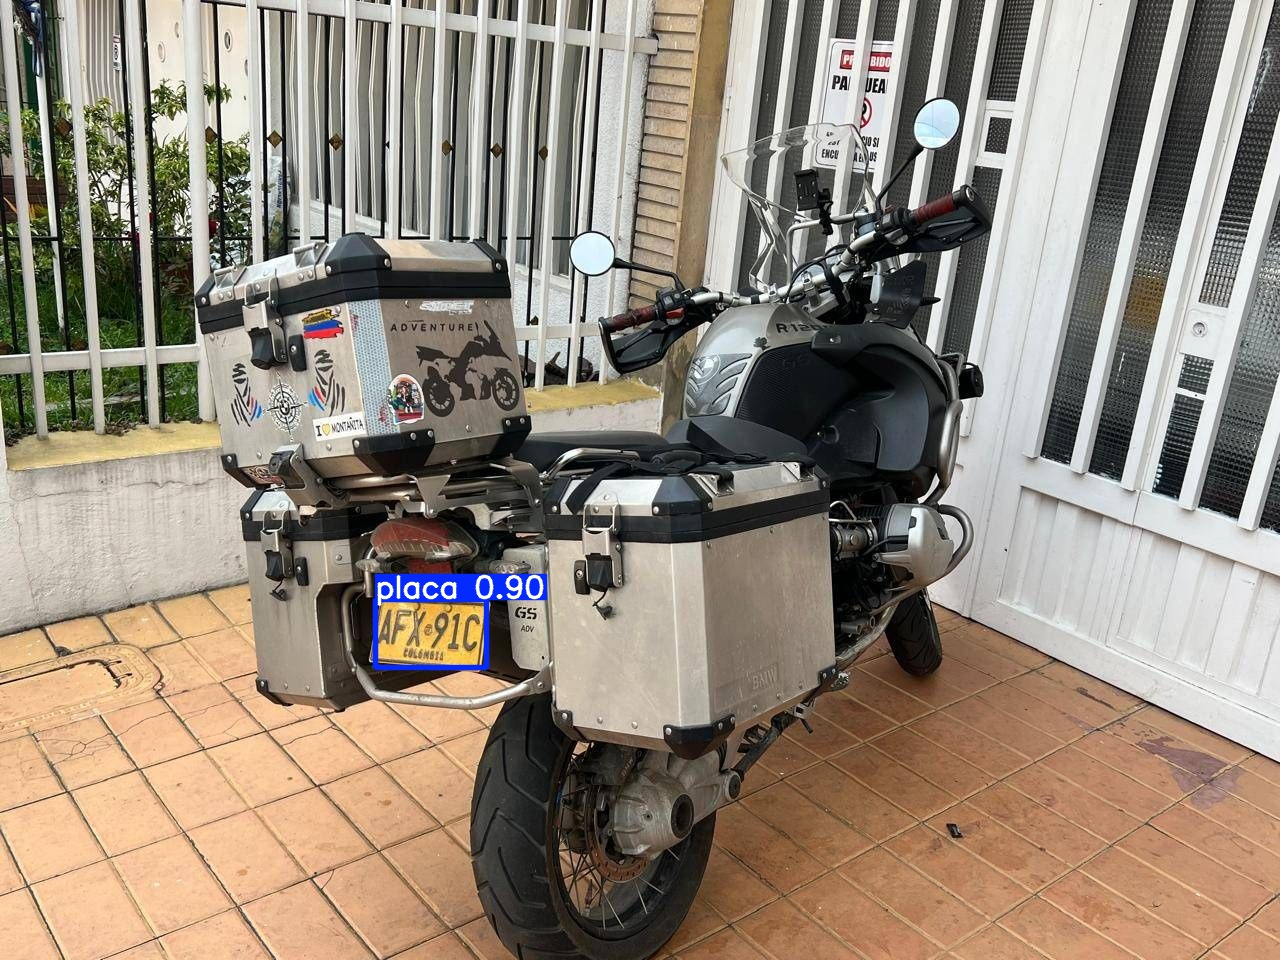

In [ ]:
display(Image.open("runs/detect/predict/AFX91C.jpg"))

In [ ]:
carpeta = "/content/Placas"
carpeta_recortes = "/content/recortes"

os.makedirs(carpeta_recortes, exist_ok=True)

data = []

for nombre_img in os.listdir(carpeta):
    if nombre_img.lower().endswith((".jpg", ".png", ".jpeg")):

        ruta = os.path.join(carpeta, nombre_img)
        img = cv2.imread(ruta)

        results = model(img)

        for r in results:

            if len(r.boxes) == 0:
                continue

            # mejor detección
            best_box = max(r.boxes, key=lambda b: float(b.conf[0]))

            # coordenadas
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # padding
            padding = 5
            h, w, _ = img.shape

            x1 = max(0, x1 - padding)
            y1 = max(0, y1 - padding)
            x2 = min(w, x2 + padding)
            y2 = min(h, y2 + padding)

            # recorte
            placa = img[y1:y2, x1:x2]

            # guardar recorte
            nombre_salida = f"recorte_{nombre_img}"
            ruta_salida = os.path.join(carpeta_recortes, nombre_salida)
            cv2.imwrite(ruta_salida, placa)

            # cálculos
            ancho = x2 - x1
            largo = y2 - y1

            # guardar datos
            data.append([
                nombre_img,
                x1, y1, x2, y2,
                ancho,
                largo,
            ])

# dataframe
df = pd.DataFrame(data, columns=[
    "imagen",
    "x1", "y1", "x2", "y2",
    "ancho",
    "largo",
])

df.to_csv("resultados_coordenadas.csv", index=False)

print("Recortes guardados en:", carpeta_recortes)



0: 640x480 1 placa, 254.6ms
Speed: 7.7ms preprocess, 254.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 2 placas, 189.4ms
Speed: 7.5ms preprocess, 189.4ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 placas, 146.1ms
Speed: 5.6ms preprocess, 146.1ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 placa, 146.5ms
Speed: 6.0ms preprocess, 146.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 placas, 149.6ms
Speed: 5.4ms preprocess, 149.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 640x480 1 placa, 152.6ms
Speed: 5.5ms preprocess, 152.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)

0: 480x640 1 placa, 151.3ms
Speed: 4.1ms preprocess, 151.3ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 placa, 145.6ms
Speed: 5.9ms preprocess, 145.6ms inference, 0.8ms postprocess per image at shap

In [ ]:
carpeta = "/content/PlacasBlancas"
carpeta_recortes = "/content/recortesPB"

os.makedirs(carpeta_recortes, exist_ok=True)

data = []

for nombre_img in os.listdir(carpeta):
    if nombre_img.lower().endswith((".jpg", ".png", ".jpeg")):

        ruta = os.path.join(carpeta, nombre_img)
        img = cv2.imread(ruta)

        results = model(img)

        for r in results:

            if len(r.boxes) == 0:
                continue

            # mejor detección
            best_box = max(r.boxes, key=lambda b: float(b.conf[0]))

            # coordenadas
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)

            # padding
            padding = 5
            h, w, _ = img.shape

            x1 = max(0, x1 - padding)
            y1 = max(0, y1 - padding)
            x2 = min(w, x2 + padding)
            y2 = min(h, y2 + padding)

            # recorte
            placa = img[y1:y2, x1:x2]

            # guardar recorte
            nombre_salida = f"recorte_{nombre_img}"
            ruta_salida = os.path.join(carpeta_recortes, nombre_salida)
            cv2.imwrite(ruta_salida, placa)

            # cálculos
            ancho = x2 - x1
            largo = y2 - y1

            # guardar datos
            data.append([
                nombre_img,
                x1, y1, x2, y2,
                ancho,
                largo,
            ])

# dataframe
df = pd.DataFrame(data, columns=[
    "imagen",
    "x1", "y1", "x2", "y2",
    "ancho",
    "largo",
])

df.to_csv("resultados_coordenadas_pb.csv", index=False)

print("Recortes guardados en:", carpeta_recortes)



0: 480x640 1 placa, 162.4ms
Speed: 5.3ms preprocess, 162.4ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 placa, 142.0ms
Speed: 4.7ms preprocess, 142.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 448x640 1 placa, 129.5ms
Speed: 3.9ms preprocess, 129.5ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

0: 480x640 1 placa, 141.2ms
Speed: 4.5ms preprocess, 141.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 placa, 136.1ms
Speed: 4.2ms preprocess, 136.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 placas, 152.6ms
Speed: 4.4ms preprocess, 152.6ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 640x640 1 placa, 192.2ms
Speed: 5.3ms preprocess, 192.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 480x640 1 placa, 137.7ms
Speed: 4.1ms preprocess, 137.7ms inference, 0.8ms postprocess per image at shape 

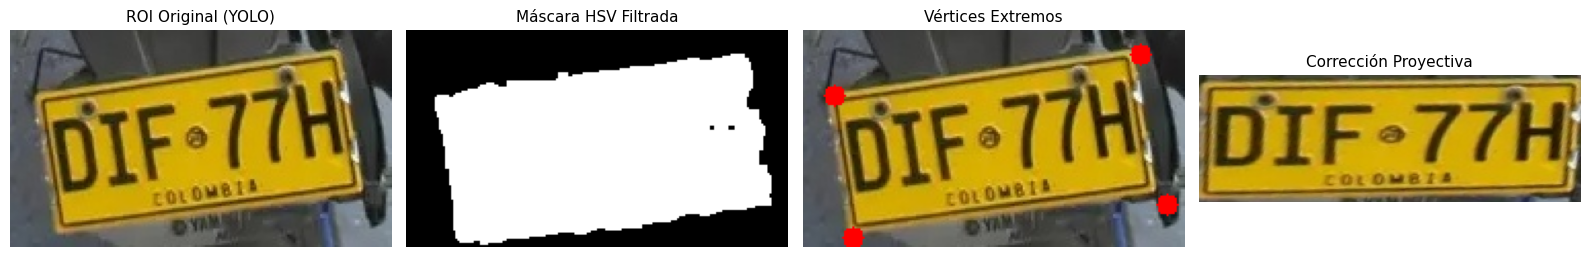

Imagen 'flujo_placa_amarilla.png' guardada con éxito.


In [ ]:
img_path = "/content/recortes/recorte_DIF77H.jpg"
img = cv2.imread(img_path)

if img is None:
    print("ruta de imagen válida.")
else:

    # Original
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Msscara HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_yellow = np.array([15, 40, 40])
    upper_yellow = np.array([40, 255, 255])
    mask_yellow = cv2.inRange(hsv, lower_yellow, upper_yellow)

    kernel = np.ones((2, 2), np.uint8)
    mask_proc = cv2.morphologyEx(mask_yellow, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_proc = cv2.morphologyEx(mask_proc, cv2.MORPH_OPEN, kernel, iterations=3)

    # Identificación de vertices
    ys, xs = np.where(mask_proc == 255)
    points = np.column_stack((xs, ys))

    top_left = points[np.argmin(points[:,0] + points[:,1])]
    top_right = points[np.argmax(points[:,0] - points[:,1])]
    bottom_left = points[np.argmin(points[:,0] - points[:,1])]
    bottom_right = points[np.argmax(points[:,0] + points[:,1])]

    # Dibujar puntos
    img_vertices = img_rgb.copy()
    vertices = [top_left, top_right, bottom_left, bottom_right]
    for pt in vertices:
        cv2.circle(img_vertices, tuple(pt), int(img.shape[0]*0.05), (255, 0, 0), -1)

    # Resultado
    pts1 = np.float32([top_left-5, top_right-5, bottom_left, bottom_right])
    width, height = 300, 100
    pts2 = np.float32([[0, 0], [width, 0], [0, height], [width, height]])
    M = cv2.getPerspectiveTransform(pts1, pts2)
    placa_homografia = cv2.warpPerspective(img_rgb, M, (width, height))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title("ROI Original (YOLO)", fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(mask_proc, cmap='gray')
    axes[1].set_title("Máscara HSV Filtrada", fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(img_vertices)
    axes[2].set_title("Vértices Extremos", fontsize=11)
    axes[2].axis('off')

    axes[3].imshow(placa_homografia)
    axes[3].set_title("Corrección Proyectiva", fontsize=11)
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig("flujo_placa_amarilla.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Imagen 'flujo_placa_amarilla.png' guardada con éxito.")

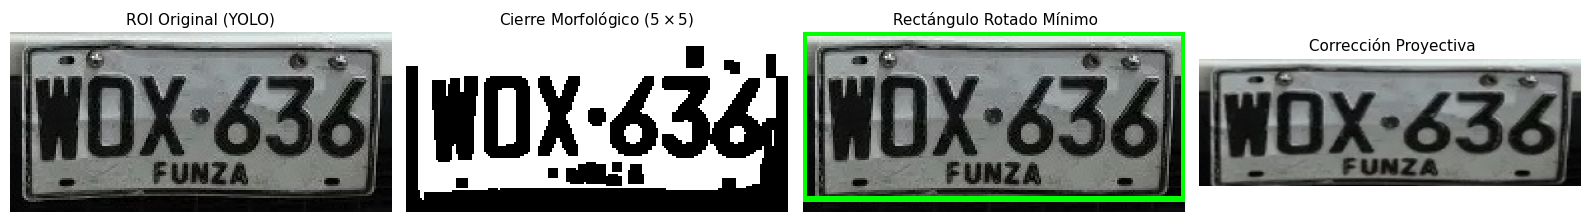

Imagen 'flujo_placa_blanca.png' guardada con éxito.


In [ ]:
img_path_blanca = "/content/recortesPB/recorte_WDX636.jpg"
img_w = cv2.imread(img_path_blanca)

if img_w is None:
    print("ruta de imagen válida.")
else:
    # Original
    img_w_rgb = cv2.cvtColor(img_w, cv2.COLOR_BGR2RGB)

    # Mascara y Cierre (5x5)
    hsv_w = cv2.cvtColor(img_w, cv2.COLOR_BGR2HSV)
    mask_w = cv2.inRange(hsv_w, np.array([0, 0, 120]), np.array([180, 60, 255]))
    kernel_w = np.ones((5,5), np.uint8)
    closed_w = cv2.morphologyEx(mask_w, cv2.MORPH_CLOSE, kernel_w)

    # Rectangulo
    contornos, _ = cv2.findContours(closed_w, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c_max = max(contornos, key=cv2.contourArea)
    rect = cv2.minAreaRect(c_max)
    box = cv2.boxPoints(rect)
    box = np.intp(box)

    # Dibujar la caja
    img_rect_orientado = img_w_rgb.copy()
    cv2.drawContours(img_rect_orientado, [box], 0, (0, 255, 0), 2)

    # Resultado
    s = box.sum(axis=1)
    diff = np.diff(box, axis=1)
    pts1 = np.zeros((4, 2), dtype="float32")
    pts1[0] = box[np.argmin(s)]
    pts1[1] = box[np.argmin(diff)]
    pts1[2] = box[np.argmax(diff)]
    pts1[3] = box[np.argmax(s)]

    M_w = cv2.getPerspectiveTransform(pts1, np.float32([[0, 0], [300, 0], [0, 100], [300, 100]]))
    placa_homografia_w = cv2.warpPerspective(img_w_rgb, M_w, (300, 100))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(img_w_rgb)
    axes[0].set_title("ROI Original (YOLO)", fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(closed_w, cmap='gray')
    axes[1].set_title("Cierre Morfológico ($5\\times5$)", fontsize=11)
    axes[1].axis('off')

    axes[2].imshow(img_rect_orientado)
    axes[2].set_title(" Rectángulo Rotado Mínimo", fontsize=11)
    axes[2].axis('off')

    axes[3].imshow(placa_homografia_w)
    axes[3].set_title(" Corrección Proyectiva", fontsize=11)
    axes[3].axis('off')

    plt.tight_layout()
    plt.savefig("flujo_placa_blanca.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Imagen 'flujo_placa_blanca.png' guardada con éxito.")

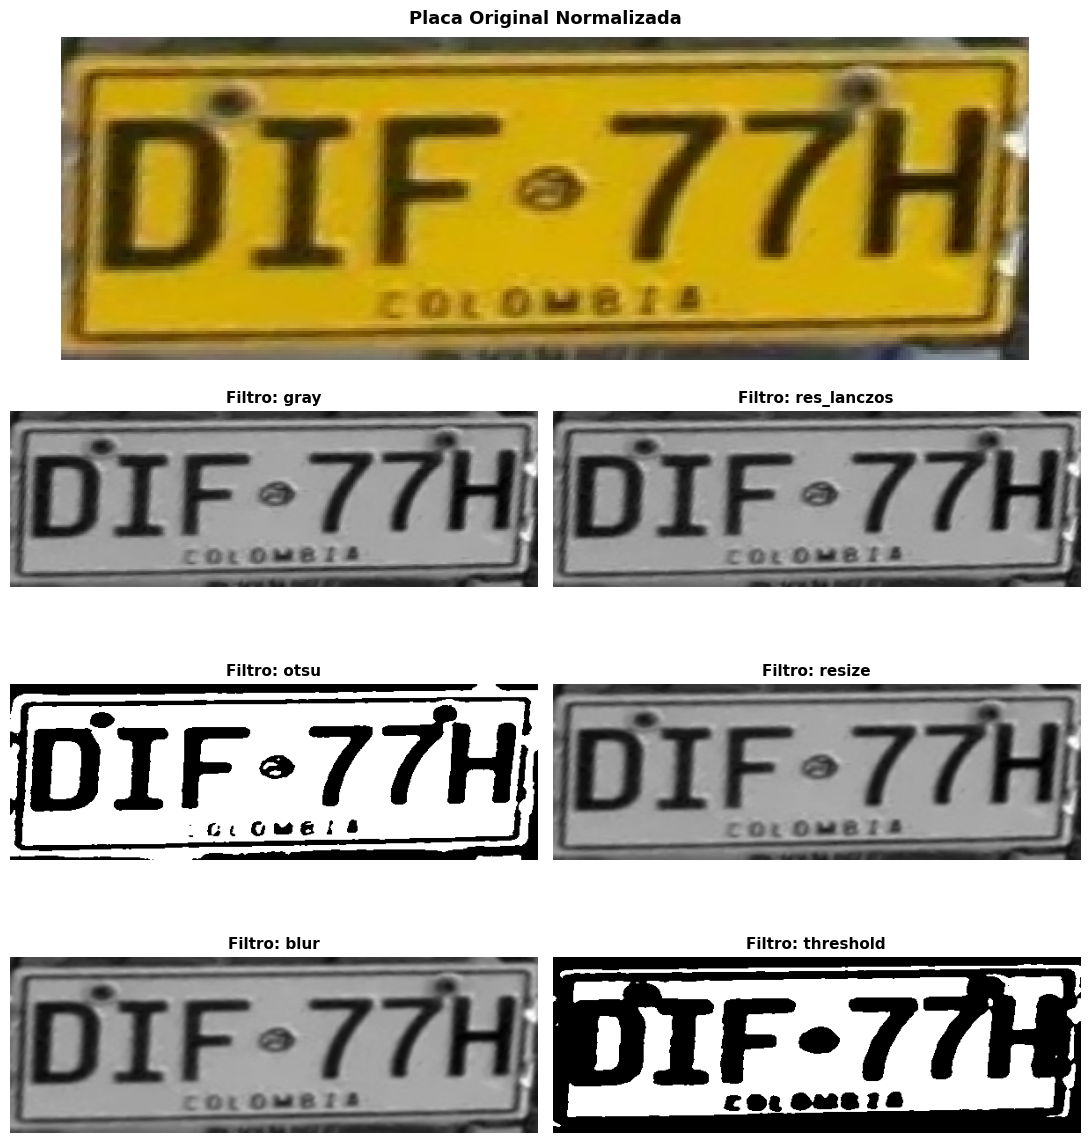

Imagen 'banco_filtros_ocr.png' generada con el formato solicitado de 1 fila superior y 2 columnas inferiores.


In [ ]:
def generar_filtros(img):
    filtros = {}
    filtros["original"] = img
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filtros["gray"] = gray
    res_lanczos = cv2.resize(gray, None, fx=2, fy=2, interpolation=cv2.INTER_LANCZOS4)
    filtros["res_lanczos"] = res_lanczos
    _, otsu = cv2.threshold(res_lanczos, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    filtros["otsu"] = otsu
    resize = cv2.resize(gray, None, fx=2, fy=2)
    filtros["resize"] = resize
    blur = cv2.GaussianBlur(resize, (3,3), 0)
    filtros["blur"] = blur
    _, thresh = cv2.threshold(blur, 150, 255, cv2.THRESH_BINARY)
    filtros["threshold"] = thresh
    return filtros

if 'placa_homografia' in locals():
    placa_bgr_base = cv2.cvtColor(placa_homografia, cv2.COLOR_RGB2BGR)
    filtros_dict = generar_filtros(placa_bgr_base)

    nombres_filtros_abajo = [k for k in filtros_dict.keys() if k != "original"]

    fig = plt.figure(figsize=(11, 12))
    gs = gridspec.GridSpec(4, 2, height_ratios=[1.2, 1, 1, 1])

    ax_orig = fig.add_subplot(gs[0, :])
    img_orig_rgb = cv2.cvtColor(filtros_dict["original"], cv2.COLOR_BGR2RGB)
    ax_orig.imshow(img_orig_rgb)
    ax_orig.set_title("Placa Original Normalizada", fontsize=13, fontweight='bold', pad=10)
    ax_orig.axis('off')

    idx_filtro = 0
    for fila in range(1, 4):
        for col in range(2):
            ax = fig.add_subplot(gs[fila, col])
            nombre = nombres_filtros_abajo[idx_filtro]
            img_proc = filtros_dict[nombre]

            ax.imshow(img_proc, cmap='gray')
            ax.set_title(f"Filtro: {nombre}", fontsize=11, fontweight='bold')
            ax.axis('off')

            idx_filtro += 1

    plt.tight_layout()
    plt.savefig("banco_filtros_ocr.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("Imagen 'banco_filtros_ocr.png' generada con el formato solicitado de 1 fila superior y 2 columnas inferiores.")
else:
    print("Primero debes ejecutar la Celda 1 para que exista la variable 'placa_homografia'.")

In [ ]:
config_ocr = "--psm 7 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

# diccionarios
NUM_A_LETRA = {"0": "O", "1": "I", "2": "Z", "4": "A", "5": "S", "8": "B"}
LETRA_A_NUM = {"O": "0", "I": "1", "J": "1", "Z": "2", "A": "4", "S": "5", "B": "8", "G": "6"}

def limpiar_y_corregir(texto):
    # limpieza basica
    texto = texto.strip().upper()
    texto = "".join(texto.split())

    if not texto:
        return ""

    # filtro de ruido frontal
    if len(texto) >= 7:
        letras_iniciales = 0
        for char in texto:
            if char.isalpha():
                letras_iniciales += 1
            else:
                break
        if letras_iniciales >= 4:
            texto = texto[1:]

    # recorte de seguridad
    texto = texto[:6]
    lista_texto = list(texto)
    n = len(lista_texto)

    # mapeo AAA 123 o AAA 12A
    for i in range(n):
        # posiciones 0, 1, 2: letras
        if i < 3:
            if lista_texto[i].isdigit():
                lista_texto[i] = NUM_A_LETRA.get(lista_texto[i], lista_texto[i])

        # posiciones 3, 4: numeros
        elif i == 3 or i == 4:
            if lista_texto[i].isalpha():
                lista_texto[i] = LETRA_A_NUM.get(lista_texto[i], lista_texto[i])

        # posicion 5: puede ser letra o numero

    return "".join(lista_texto)


def validar_gramatica_colombiana(texto):
    if len(texto) != 6:
        return "INVALIDO"

    son_letras_ini = all(c.isalpha() for c in texto[0:3])
    son_numeros_mid = all(c.isdigit() for c in texto[3:5])

    if son_letras_ini and son_numeros_mid:
        # formato carros
        if texto[5].isdigit():
            return "CARRO ($L^3N^3$)"
        # formato motos
        elif texto[5].isalpha() and (texto[5] in "ABCDEFGHI"):
            return "MOTO ($L^3N^2L^1$)"

    return "INVALIDO"

# filtros
if 'filtros_dict' in locals():
    lecturas_de_esta_placa = []
    print("PROCESANDO LECTURAS DE TEXTO POR FILTRO")

    for nombre_filtro, img_proc in filtros_dict.items():
        texto_raw = pytesseract.image_to_string(img_proc, config=config_ocr)

        texto_corregido = limpiar_y_corregir(texto_raw)

        if texto_corregido:
            lecturas_de_esta_placa.append(texto_corregido)
            print(f"Filtro [{nombre_filtro.upper()}]: texto procesado -> {texto_corregido}")
        else:
            print(f"Filtro [{nombre_filtro.upper()}]: sin lectura legible.")

    print("\nANALISIS DE CONSISTENCIA ESTADÍSTICA")
    if lecturas_de_esta_placa:
        conteo_votos = collections.Counter(lecturas_de_esta_placa)
        cadena_ganadora, votos = conteo_votos.most_common(1)[0]

        print(f"Votacion por mayoria: '{cadena_ganadora}' ({votos}/{len(filtros_dict)} filtros)")

        tipo_vehiculo = validar_gramatica_colombiana(cadena_ganadora)

        print("\nVERIFICACION ESTRUCTURAL")
        if tipo_vehiculo != "INVALIDO":
            print(f"Aprobado. cumple con la gramática de: {tipo_vehiculo}")
            placa_final_sistema = cadena_ganadora
        else:
            print("La cadena no sigue las reglas")
            print("Se conserva el resultado de la votación sin alterar su forma.")
            placa_final_sistema = cadena_ganadora

        print(f" RESULTADO FINAL DEL PROTOTIPO: {placa_final_sistema}")
    else:
        print("Error: ningun filtro genero caracteres validos para analizar.")
else:
    print("Primero ejecutar la celda del banco de filtros para que 'filtros_dict' exista en memoria.")

PROCESANDO LECTURAS DE TEXTO POR FILTRO
Filtro [ORIGINAL]: sin lectura legible.
Filtro [GRAY]: texto procesado -> DIF77H
Filtro [RES_LANCZOS]: texto procesado -> DIF77H
Filtro [OTSU]: texto procesado -> DIF77H
Filtro [RESIZE]: texto procesado -> DIF77H
Filtro [BLUR]: texto procesado -> DIF77H
Filtro [THRESHOLD]: texto procesado -> DIF77H

ANALISIS DE CONSISTENCIA ESTADÍSTICA
Votacion por mayoria: 'DIF77H' (6/7 filtros)

VERIFICACION ESTRUCTURAL
Aprobado. cumple con la gramática de: MOTO ($L^3N^2L^1$)
 RESULTADO FINAL DEL PROTOTIPO: DIF77H
